# 04: Dead reckoning (E1)

**Goal.** Integrate the IMU forward with no corrections, and measure how fast the estimate drifts away from the truth. This answers E1: *how bad is the problem?*

**Why it matters beyond E1.** Dead reckoning is the Kalman filter's **prediction step run alone**. The same motion model reappears in `ekf.py` and `ukf.py`, so this notebook is really writing half the EKF, in isolation, where it can be debugged without covariances in the way. If the model is wrong here, every later estimator is wrong in the same way.

**Workflow.** Implement each function in this notebook, where plots are one cell away. Once a function works, move it into `src/dead_reckoning.py`, whose stubs match these signatures.

---

In [1]:
''' DO NOT CHANGE THE CODE BELOW '''
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

REPO = Path.cwd()
if not (REPO / "src").exists():
    REPO = REPO.parent
sys.path.insert(0, str(REPO))

from src.align import build_timeline
from src.frames import add_enu, azimuth_to_yaw, origin_from_reference, wrap_angle

P = REPO / "data" / "processed" / "Urban04"
imu = pd.read_parquet(P / "imu.parquet")
gnss = pd.read_parquet(P / "gnss.parquet")
odometry = pd.read_parquet(P / "odometry.parquet")
reference = pd.read_parquet(P / "reference.parquet")

origin = origin_from_reference(reference)
reference = add_enu(reference, origin)
reference["yaw"] = azimuth_to_yaw(reference["azimuth"])
gnss = add_enu(gnss, origin, alt_col="alt")

timeline = build_timeline(imu, gnss, odometry, reference)
print(f"{len(timeline)} rows, {timeline.t.iloc[-1]:.0f} s, columns:")
print(list(timeline.columns))

106500 rows, 1065 s, columns:
['t_ns', 't', 'wx', 'wy', 'wz', 'ax', 'ay', 'az', 'dt', 'gnss_new', 'gnss_row', 'odometry_new', 'odometry_row', 'ref_east', 'ref_north', 'ref_yaw']


In [2]:
odometry = pd.DataFrame({"speed": [10.0]})
print(odometry.shape)
print(len(odometry["speed"]))

(1, 1)
1


## 1. The motion model

### State and input

The state is a planar pose plus forward speed,

$$\mathbf{x}_k = \begin{bmatrix} E_k & N_k & \theta_k & v_k \end{bmatrix}^{\mathsf{T}}$$

with $E$ east and $N$ north in metres, $\theta$ the heading in radians counterclockwise from east, and $v$ the forward speed in m/s.

The **input** is the IMU,

$$\mathbf{u}_k = \begin{bmatrix} \omega_{z,k} & a_{x,k} \end{bmatrix}^{\mathsf{T}}$$

the yaw rate and the forward acceleration. Note carefully: the IMU is $\mathbf{u}$, **not** a measurement $\mathbf{y}$. It drives the model rather than correcting it. There is no $\mathbf{y}$ anywhere in this notebook.

### Continuous form

$$\dot{\theta} = \omega_z - b \qquad \dot{v} = a_x \qquad \dot{E} = v\cos\theta \qquad \dot{N} = v\sin\theta$$

where $b$ is the gyroscope's turn-on bias, estimated once and then held fixed.

This is a **kinematic** model, not a dynamic one: no masses, forces or tyre models appear. A dynamic model exists to predict acceleration from forces, and the IMU measures the acceleration directly, so there is nothing left to predict. The price is that the model inherits every error in the sensor, with nothing to correct it.

### Discrete form, which is what you implement

Forward Euler at $\Delta t = 10$ ms:

$$\theta_{k+1} = \mathrm{wrap}\!\left(\theta_k + (\omega_{z,k} - b)\,\Delta t\right)$$
$$v_{k+1} = v_k + a_{x,k}\,\Delta t$$
$$E_{k+1} = E_k + v_{k+1}\cos\theta_{k+1}\,\Delta t$$
$$N_{k+1} = N_k + v_{k+1}\sin\theta_{k+1}\,\Delta t$$

Euler is deliberate rather than lazy. Over 10 ms the vehicle moves at most 12.5 cm and turns at most 0.27 degrees, so a higher-order scheme would buy far less than the sensor errors cost. Using the same first-order step the EKF will use also keeps the two comparable.

**$\mathrm{wrap}$ is not optional.** Heading lives on a circle; without wrapping, $\theta$ grows without bound and every later comparison against the reference breaks. Use `frames.wrap_angle`.

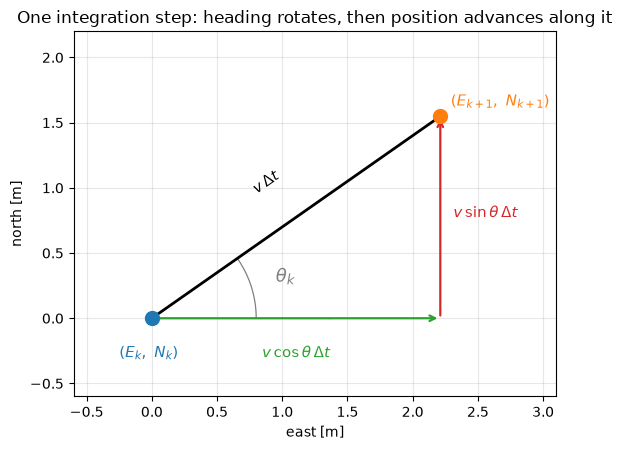

In [3]:
''' DO NOT CHANGE THE CODE BELOW: a drawing of one integration step '''
fig, ax = plt.subplots(figsize=(7.5, 4.6))

E0, N0, yaw0, v, dt = 0.0, 0.0, np.radians(35), 3.0, 0.9
dE, dN = v * np.cos(yaw0) * dt, v * np.sin(yaw0) * dt

ax.plot([E0, E0 + dE], [N0, N0 + dN], "k-", lw=2, zorder=3)
ax.plot(E0, N0, "o", ms=10, color="tab:blue", zorder=4)
ax.plot(E0 + dE, N0 + dN, "o", ms=10, color="tab:orange", zorder=4)
ax.annotate("", xy=(E0 + dE, N0), xytext=(E0, N0),
            arrowprops=dict(arrowstyle="->", color="tab:green", lw=1.6))
ax.annotate("", xy=(E0 + dE, N0 + dN), xytext=(E0 + dE, N0),
            arrowprops=dict(arrowstyle="->", color="tab:red", lw=1.6))
ax.plot([E0, E0 + 1.4], [N0, N0], color="grey", lw=0.9, ls=":")

th = np.linspace(0, yaw0, 40)
ax.plot(E0 + 0.8 * np.cos(th), N0 + 0.8 * np.sin(th), color="grey", lw=0.9)
ax.text(E0 + 0.95, N0 + 0.28, r"$\theta_k$", fontsize=13, color="grey")

ax.text(E0 - 0.25, N0 - 0.30, r"$(E_k,\ N_k)$", fontsize=11, color="tab:blue")
ax.text(E0 + dE + 0.08, N0 + dN + 0.08, r"$(E_{k+1},\ N_{k+1})$", fontsize=11, color="tab:orange")
ax.text(E0 + dE / 2, N0 - 0.30, r"$v\,\cos\theta\,\Delta t$", fontsize=11, color="tab:green", ha="center")
ax.text(E0 + dE + 0.10, N0 + dN / 2, r"$v\,\sin\theta\,\Delta t$", fontsize=11, color="tab:red")
ax.text(E0 + dE / 2 - 0.35, N0 + dN / 2 + 0.18, r"$v\,\Delta t$", fontsize=11, rotation=35)

ax.set(xlabel="east [m]", ylabel="north [m]",
       title="One integration step: heading rotates, then position advances along it")
ax.set_aspect("equal"); ax.grid(alpha=0.3)
ax.set_xlim(-0.6, 3.1); ax.set_ylim(-0.6, 2.2)
fig.tight_layout()

## 2. Where the numbers come from

Three quantities have to be set before the loop can run, and all three come from the data rather than from a datasheet.

### The stationary period

Every NavINST trajectory begins and ends with roughly two minutes parked. Detect it from the **odometer**, not the IMU: wheel speed reads exactly zero when stopped, whereas the IMU always shows noise.

### The gyro bias

While genuinely still, the true angular rate is zero, so whatever the gyro reports is bias plus noise:

$$\tilde{\omega}_z = \underbrace{0}_{\text{true rate}} + b + \eta, \qquad \eta \sim \mathcal{N}(0, \sigma^2)$$

Averaging over $M$ stationary samples kills the noise and leaves the bias:

$$\hat{b} = \frac{1}{M}\sum_{k=1}^{M} \tilde{\omega}_{z,k}, \qquad \mathrm{std}(\hat{b}) = \frac{\sigma}{\sqrt{M}}$$

That $\sqrt{M}$ is why two minutes is generous rather than wasteful. In Urban04 the bias and the noise turn out to be **the same size**, so a single sample tells you nothing, while the average of 9,860 has a standard error near 0.001 deg/s.

### The initial pose

Taken from the reference. This is the one place an estimator reads truth, and it needs justifying in the README: heading cannot come from GNSS, because a parked vehicle has no course and differencing two fixes 1.2 m apart over 0.25 s gives nonsense, and the magnetometer is excluded. Starting from a known pose also means E1 measures **drift**, not initialisation error.

#### Task 1

Fill in `find_stationary_window()`. Return the start and end time of the **initial** stationary period, in seconds.

The odometer is quantised to 1 km/h = 0.278 m/s, so any threshold strictly between 0 and that step works.

Hint: `timeline` has an `odometry_row` column indexing into `odometry`. A simpler route is to use `odometry` directly, since you only need times.

In [4]:
def find_stationary_window(odometry, speed_threshold=0.1):
    """Return (t_start, t_end) of the initial stationary period, in seconds."""
    ''' YOUR ANSWER HERE '''
    t_start = odometry.iloc[0, 2]
    for i in range(len(odometry)):
        if odometry["speed"].iloc[i] > speed_threshold:
            t_end = odometry["t"].iloc[i]
            break
    return t_start, t_end


t_start, t_end = find_stationary_window(odometry)
print(f"stationary from t = {t_start:.1f} s to t = {t_end:.1f} s  ({t_end - t_start:.1f} s)")
print(f"the run then ends with another {odometry.t.iloc[-1] - odometry.loc[odometry.speed > 0.1, 't'].iloc[-1]:.1f} s parked")

IndexError: index 2 is out of bounds for axis 0 with size 1

#### Task 2

Fill in `estimate_gyro_bias()`. Average the named gyro axis over the stationary window.

Return the bias in **rad/s**, since that is the unit the loop works in.

In [ ]:
print(type(imu))
print(list(imu))

print(imu["t"][0])
print(imu["t"][1])



<class 'pandas.DataFrame'>
['t_ns', 't', 'wx', 'wy', 'wz', 'ax', 'ay', 'az']
0.00731492
0.017314911


In [ ]:
def estimate_gyro_bias(imu, t_start, t_end, axis="wz"):
    """Mean of the named gyro axis over a stationary window, in rad/s."""
    ''' YOUR ANSWER HERE '''
    still = imu[(imu.t >= t_start) & (imu.t <= t_end)]
    values = still[axis].to_numpy()
    M = len(values)
    
    total = 0.0
    for k in range(M):
        total += values[k]

    bias = (1 / M) * total
    return bias
        


bias = estimate_gyro_bias(imu, t_start, t_end)
still = imu[(imu.t >= t_start) & (imu.t <= t_end)]
print(f"bias            {np.degrees(bias):+.4f} deg/s   ({bias:+.6f} rad/s)")
print(f"sample sd       {np.degrees(still.wz.std()):.4f} deg/s")
print(f"samples         {len(still)}")
print(f"std error of b  {np.degrees(still.wz.std() / np.sqrt(len(still))):.4f} deg/s")

bias            +0.0977 deg/s   (+0.001705 rad/s)
sample sd       0.1012 deg/s
samples         9860
std error of b  0.0010 deg/s


#### Discuss

- The bias and the sample standard deviation come out almost equal. What would happen if you estimated the bias from a single sample, or from one second rather than ninety-eight?
- The run is also stationary for its last 125 s. Why is the **leading** window the right one to use, and what would a bias estimated from the trailing window actually be measuring?

> *your answer here*

## 3. Why the bias matters so much

An uncorrected heading bias $b$ does not stay small. After $t$ seconds the heading is wrong by $bt$, and a vehicle travelling at speed $v$ is pushed sideways by

$$e_{\text{cross-track}} \approx \tfrac{1}{2} v\, b\, t^2$$

The $t^2$ is what makes this the dominant error. Run the cell below to see the measured bias turned into metres.

In [ ]:
''' DO NOT CHANGE THE CODE BELOW '''
v_typ = odometry.loc[odometry.speed > 0.1, "speed"].mean()
print(f"typical moving speed {v_typ:.1f} m/s\n")
print(f"{'outage [s]':>11} {'heading error [deg]':>20} {'cross-track [m]':>17}")
for t_out in (5, 10, 30, 60):
    print(f"{t_out:11d} {np.degrees(bias * t_out):20.2f} {0.5 * v_typ * bias * t_out**2:17.2f}")
print("\nand if the bias were NOT removed at all, the same table with b as measured:")
print("(this is exactly what Task 3 lets you test, by passing bias=0.0)")

typical moving speed 6.9 m/s

 outage [s]  heading error [deg]   cross-track [m]
          5                 0.49              0.15
         10                 0.98              0.59
         30                 2.93              5.33
         60                 5.86             21.32

and if the bias were NOT removed at all, the same table with b as measured:
(this is exactly what Task 3 lets you test, by passing bias=0.0)


## 4. The integration loop

#### Task 3

Fill in `dead_reckon()`. One prediction step per row of `timeline`, nothing else.

Two speed sources:

| `speed_source` | what happens to $v$ |
|---|---|
| `"inertial"` | integrate: $v \leftarrow v + a_x \Delta t$ |
| `"odometer"` | whenever `odometry_new` is True, set $v$ to that reading and hold it until the next |

Things to get right:

- **Wrap the heading every step**, with `wrap_angle`.
- **Subtract the bias** from `wz` before integrating.
- Use the row's own `dt`, not a hard-coded 0.01.
- `odometry_row` indexes into `odometry`; it is `-1` on rows where nothing arrived.
- Return one row per input row, so the output lines up with `ref_*` without further alignment.

A plain `for` loop is fine here. The state at step $k$ depends on step $k-1$, so this cannot be vectorised the way `align.py` was.

In [ ]:
print(type(timeline))
print(timeline.shape)
print(list(timeline))
print(timeline["ax"].iloc[0])
print(timeline.ax.iloc[0])
print(bias)

<class 'pandas.DataFrame'>
(106500, 16)
['t_ns', 't', 'wx', 'wy', 'wz', 'ax', 'ay', 'az', 'dt', 'gnss_new', 'gnss_row', 'odometry_new', 'odometry_row', 'ref_east', 'ref_north', 'ref_yaw']
-0.011546716094017029
-0.011546716094017029
0.001704645026936318


In [ ]:
def dead_reckon(timeline, odometry, east0, north0, yaw0, speed0, bias, speed_source="odometer"):
    """Integrate the IMU open loop.

    Returns a DataFrame with t, east, north, yaw, speed: one row per input row.
    """
    ''' YOUR ANSWER HERE '''
    speeds = []
    easts = []
    norths = []
    yaws = []
    
    speed, yaw, east, north = speed0, yaw0, east0, north0
    
    wz = timeline["wz"].to_numpy()
    ax = timeline["ax"].to_numpy()
    dt = timeline["dt"].to_numpy()
    odo_new = timeline["odometry_new"].to_numpy()
    odo_row = timeline["odometry_row"].to_numpy()
    odo_speed = odometry["speed"].to_numpy()
    
    for k in range(len(timeline)):
        yaw = wrap_angle(yaw + (wz[k] - bias) * dt[k])
        
        if speed_source == "inertial":
            speed = speed + ax[k] * dt[k]
        elif odo_new[k]:
            speed = odo_speed[odo_row[k]]
            
        east = east + (speed * np.cos(yaw)) * dt[k]
        north = north + (speed * np.sin(yaw)) * dt[k]
        
        speeds.append(speed)
        yaws.append(yaw)
        easts.append(east)
        norths.append(north)

    return pd.DataFrame({
        "t": timeline["t"].to_numpy(),
        "east": easts,
        "north": norths,
        "yaw": yaws,
        "speed": speeds,
    }) 
        

dr_odo = dead_reckon(
    timeline, odometry,
    east0=timeline.ref_east.iloc[0], north0=timeline.ref_north.iloc[0],
    yaw0=timeline.ref_yaw.iloc[0], speed0=0.0, bias=bias, speed_source="odometer",
)
dr_ins = dead_reckon(
    timeline, odometry,
    east0=timeline.ref_east.iloc[0], north0=timeline.ref_north.iloc[0],
    yaw0=timeline.ref_yaw.iloc[0], speed0=0.0, bias=bias, speed_source="inertial",
)
print(dr_odo.head(3).to_string())

          t     east     north       yaw  speed
0  0.007315 -0.00024  0.000175  0.073282    0.0
1  0.017315 -0.00024  0.000175  0.073257    0.0
2  0.027315 -0.00024  0.000175  0.073221    0.0


In [ ]:
''' DO NOT CHANGE THE CODE BELOW: plotting helpers '''

def horizontal_error(estimate, timeline):
    """Unaligned horizontal error against the reference, metres."""
    return np.hypot(estimate.east - timeline.ref_east, estimate.north - timeline.ref_north)


def plot_dead_reckoning(estimates, timeline, titles):
    fig, axes = plt.subplots(1, len(estimates) + 1, figsize=(5 * (len(estimates) + 1), 4.6))

    for ax, est, title in zip(axes, estimates, titles):
        ax.plot(timeline.ref_east, timeline.ref_north, lw=1.4, color="k", label="reference")
        ax.plot(est.east, est.north, lw=1.0, color="tab:red", label="dead reckoning")
        ax.plot(timeline.ref_east.iloc[0], timeline.ref_north.iloc[0], "o", ms=7, color="tab:green")
        ax.set(title=title, xlabel="east [m]", ylabel="north [m]")
        ax.set_aspect("equal"); ax.grid(alpha=0.3); ax.legend(fontsize=8)

    for est, title in zip(estimates, titles):
        axes[-1].plot(est.t, horizontal_error(est, timeline), lw=1.0, label=title)
    axes[-1].set(title="horizontal error, no alignment", xlabel="t [s]",
                 ylabel="error [m]", yscale="log")
    axes[-1].grid(alpha=0.3, which="both"); axes[-1].legend(fontsize=8)

    fig.tight_layout()
    return fig


def summarise(estimate, timeline, label, window=300.0):
    err = horizontal_error(estimate, timeline)
    moving = timeline.t >= t_end
    w = moving & (timeline.t <= t_end + window)
    return {
        "run": label,
        "final error [m]": round(err.iloc[-1], 2),
        "max error [m]": round(err.max(), 2),
        "RMSE whole run [m]": round(float(np.sqrt((err**2).mean())), 2),
        f"RMSE first {window:.0f} s moving [m]": round(float(np.sqrt((err[w] ** 2).mean())), 2),
    }

,run,final error [m],max error [m],RMSE whole run [m],RMSE first 300 s moving [m]
0,IMU + odometer,7.63,84.66,35.76,5.67
1,IMU only,10428.62,10428.62,4421.64,2249.87


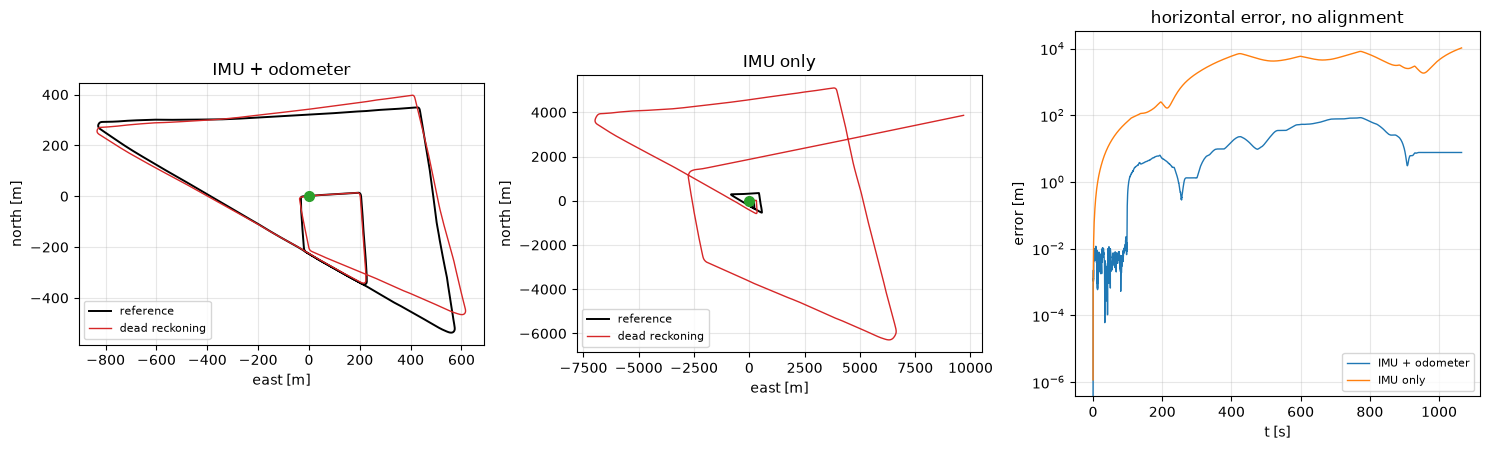

In [ ]:
plot_dead_reckoning([dr_odo, dr_ins], timeline, ["IMU + odometer", "IMU only"])
pd.DataFrame([summarise(dr_odo, timeline, "IMU + odometer"),
              summarise(dr_ins, timeline, "IMU only")])

#### Discuss

- The error axis is logarithmic. Why is that necessary, and what does that tell you about the two modes?
- The published NavINST baseline for Urban04 is **13.72 m** ATE for INS + odometer + non-holonomic constraint over a 5-minute window. How does your odometer run compare, and what differences between the two setups should be stated before claiming anything?
- The IMU-only run is far worse than the bias arithmetic in section 3 predicts. That arithmetic only covered **heading**. What else is being integrated, and why is it so much worse?
- Look at the shape of the IMU-only trajectory, not just its size. What does it tell you about *which* part of the state went wrong first?

> *your answer here*

## 5. What each error source contributes

#### Task 4

Re-run the odometer mode with the bias **not** removed, by passing `bias=0.0`, and compare. This isolates one term: everything else is identical.

Then try a deliberately wrong initial heading, a degree or two out, and see what a static heading error costs over the run.

In [ ]:
''' YOUR ANSWER HERE '''

' YOUR ANSWER HERE '

#### Discuss

- How much of the odometer run's error is the gyro bias, and how much is everything else?
- A one degree initial heading error is a constant, not a growing one. Why does it still produce an error that grows with distance travelled?
- Based on these numbers, what should the EKF's GNSS updates fix first?

> *your answer here*

---

### Next

1. Move the three working functions into `src/dead_reckoning.py`, matching the stub signatures there.
2. Write `src/metrics.py`, emitting long format: one row per `(run_id, metric_name, value)`.
3. Save the figure into `results/` and put the headline number in the README. That is the gate for making the repository public.